# 04b_W: Women's Matchup Building

**Prerequisite:** Run `04a_W_feature_building.ipynb` first

### Same approach as men's 04b
- Cross-season: Season S-1 stats -> predict Season S regular games
- Same-season: Season S stats -> predict Season S tournament
- No Massey rankings (POM, SAG, Composite) — women's only has 15 features vs 18 for men's

**Output:** `processed/matchup_features_W.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_regular_season_results, load_tourney_results,
    load_teams, PROCESSED_DIR
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

GENDER = 'W'
YEAR_START = 2010

teams = load_teams(GENDER)
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

## 1. Load Team Features

In [2]:
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_W.csv')
print(f"Women's team features: {team_features.shape}")
print(f"Seasons: {team_features['Season'].min()} to {team_features['Season'].max()}")
print(f"Columns: {team_features.columns.tolist()}")

Women's team features: (5966, 20)
Seasons: 2010 to 2026
Columns: ['Season', 'TeamID', 'Games', 'Wins', 'Losses', 'WinPct', 'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin', 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off', 'Elo_RegSeason', 'SeedNum', 'IsSeeded', 'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']


## 2. Load Game Data

In [3]:
regular = load_regular_season_results(GENDER)
regular = regular[regular['Season'] >= YEAR_START]
print(f"Regular season games: {len(regular):,}")

tourney = load_tourney_results(GENDER)
tourney = tourney[tourney['Season'] >= YEAR_START]
print(f"Tournament games: {len(tourney):,}")

Regular season games: 85,726
Tournament games: 961


## 3. Build Matchup Helper

In [4]:
def build_matchup_row(season, wteam, lteam, features_df, feature_season, diff_cols, game_type):
    """Build one matchup row using features from feature_season."""
    team1 = min(wteam, lteam)
    team2 = max(wteam, lteam)
    target = 1 if wteam == team1 else 0
    
    t1 = features_df[(features_df['Season'] == feature_season) & (features_df['TeamID'] == team1)]
    t2 = features_df[(features_df['Season'] == feature_season) & (features_df['TeamID'] == team2)]
    
    if len(t1) == 0 or len(t2) == 0:
        return None
    
    t1, t2 = t1.iloc[0], t2.iloc[0]
    row = {'Season': season, 'Team1': team1, 'Team2': team2,
           'Target': target, 'GameType': game_type}
    
    for col in diff_cols:
        val1, val2 = t1.get(col, np.nan), t2.get(col, np.nan)
        row[f'{col}_Diff'] = val1 - val2 if pd.notna(val1) and pd.notna(val2) else np.nan
    
    return row

print("Helper function ready.")

Helper function ready.


## 4. Build Regular Season Matchups (Cross-Season)

In [5]:
# Women's features — NO Massey rankings
diff_features = ['WinPct', 'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin',
                 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off',
                 'Elo_RegSeason',
                 'SeedNum', 'IsSeeded',
                 'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']

print(f"Diff features: {len(diff_features)}")
print("Building regular season matchups (cross-season)...")
print("This may take a few minutes.\n")

reg_matchup_rows = []
skipped = 0

for _, game in regular.iterrows():
    season = game['Season']
    prev_season = season - 1
    
    if prev_season < YEAR_START:
        skipped += 1
        continue
    
    row = build_matchup_row(season, game['WTeamID'], game['LTeamID'],
                           team_features, prev_season, diff_features, 'Regular')
    if row:
        reg_matchup_rows.append(row)
    else:
        skipped += 1

reg_matchups = pd.DataFrame(reg_matchup_rows)
print(f"Regular season matchups: {len(reg_matchups):,}")
print(f"Skipped: {skipped:,}")
print(f"Seasons: {reg_matchups['Season'].min()} to {reg_matchups['Season'].max()}")
print(f"Target: {reg_matchups['Target'].value_counts().to_dict()}")

Diff features: 15
Building regular season matchups (cross-season)...
This may take a few minutes.

Regular season matchups: 79,740
Skipped: 5,986
Seasons: 2011 to 2026
Target: {1: 40297, 0: 39443}


## 5. Build Tournament Matchups (Same-Season)

In [6]:
print("Building tournament matchups (same-season)...\n")

tourney_matchup_rows = []
for _, game in tourney.iterrows():
    row = build_matchup_row(game['Season'], game['WTeamID'], game['LTeamID'],
                           team_features, game['Season'], diff_features, 'Tournament')
    if row:
        tourney_matchup_rows.append(row)

tourney_matchups = pd.DataFrame(tourney_matchup_rows)
print(f"Tournament matchups: {len(tourney_matchups):,}")
print(f"Seasons: {tourney_matchups['Season'].min()} to {tourney_matchups['Season'].max()}")
print(f"Target: {tourney_matchups['Target'].value_counts().to_dict()}")

Building tournament matchups (same-season)...

Tournament matchups: 961
Seasons: 2010 to 2025
Target: {1: 485, 0: 476}


## 6. Combine & Summary

In [7]:
matchups = pd.concat([reg_matchups, tourney_matchups], ignore_index=True)

print(f"{'='*60}")
print(f"WOMEN'S COMBINED MATCHUP DATASET")
print(f"{'='*60}")
print(f"Total matchups: {len(matchups):,}")
print(f"  Regular season: {len(reg_matchups):,}")
print(f"  Tournament:     {len(tourney_matchups):,}")
print(f"\nTarget: {matchups['Target'].value_counts().to_dict()}")
print(f"\nFeature completeness:")
for col in [c for c in matchups.columns if c.endswith('_Diff')]:
    pct = 100 * matchups[col].notna().sum() / len(matchups)
    print(f"  {col}: {pct:.0f}%")

WOMEN'S COMBINED MATCHUP DATASET
Total matchups: 80,701
  Regular season: 79,740
  Tournament:     961

Target: {1: 40782, 0: 39919}

Feature completeness:
  WinPct_Diff: 100%
  AvgPointsFor_Diff: 100%
  AvgPointsAgainst_Diff: 100%
  AvgMargin_Diff: 100%
  eFG_Off_Diff: 100%
  TORate_Off_Diff: 100%
  ORBRate_Off_Diff: 100%
  FTRate_Off_Diff: 100%
  Elo_RegSeason_Diff: 100%
  SeedNum_Diff: 100%
  IsSeeded_Diff: 100%
  ConfStrength_Rank_Diff: 100%
  Last15WinPct_Diff: 100%
  Last15AvgMargin_Diff: 100%
  ConfTourneyChamp_Diff: 100%


## 7. Visualization

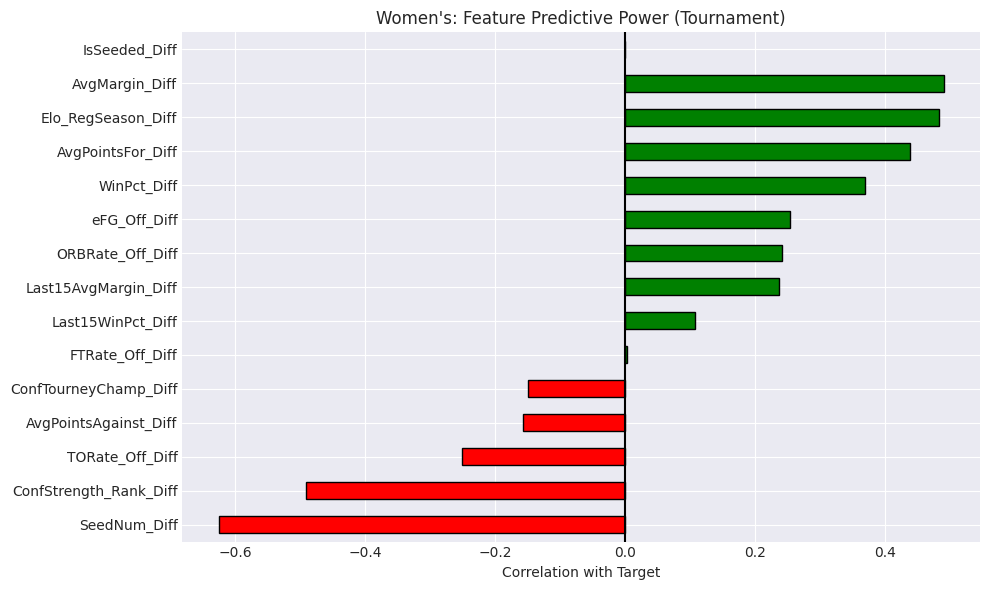

In [8]:
# Feature predictive power in tournament games
diff_cols = [c for c in tourney_matchups.columns if c.endswith('_Diff')]
target_corr = tourney_matchups[diff_cols + ['Target']].corr()['Target'].drop('Target').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v > 0 else 'red' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Correlation with Target')
ax.set_title("Women's: Feature Predictive Power (Tournament)")
ax.axvline(0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

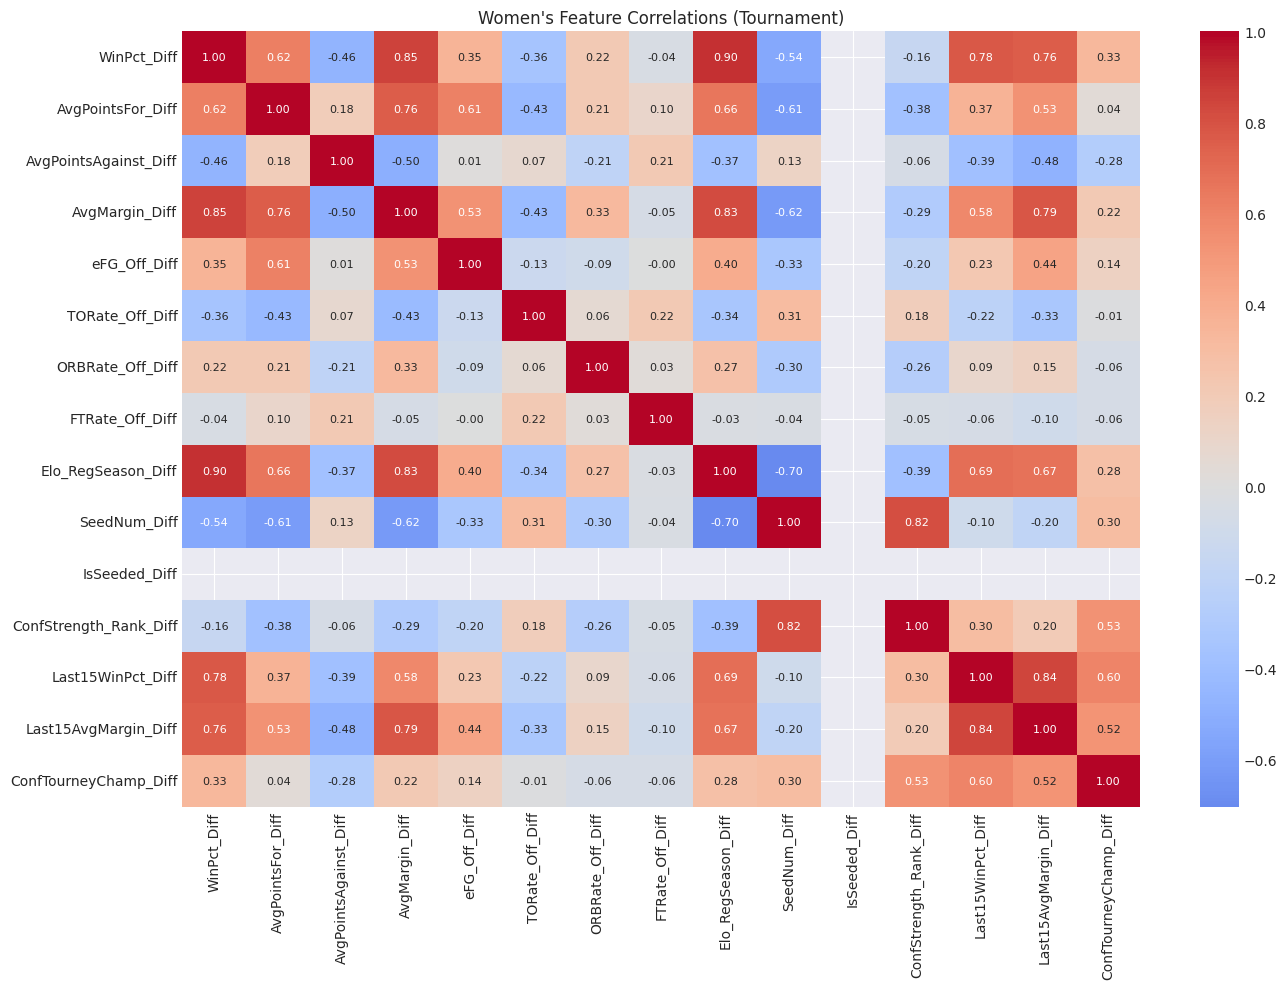

Highly correlated pairs (|r| > 0.7):
  WinPct_Diff <-> AvgMargin_Diff: 0.85
  WinPct_Diff <-> Elo_RegSeason_Diff: 0.90
  WinPct_Diff <-> Last15WinPct_Diff: 0.78
  WinPct_Diff <-> Last15AvgMargin_Diff: 0.76
  AvgPointsFor_Diff <-> AvgMargin_Diff: 0.76
  AvgMargin_Diff <-> Elo_RegSeason_Diff: 0.83
  AvgMargin_Diff <-> Last15AvgMargin_Diff: 0.79
  Elo_RegSeason_Diff <-> SeedNum_Diff: -0.70
  SeedNum_Diff <-> ConfStrength_Rank_Diff: 0.82
  Last15WinPct_Diff <-> Last15AvgMargin_Diff: 0.84


In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = tourney_matchups[diff_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8})
ax.set_title("Women's Feature Correlations (Tournament)")
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.7):")
for i in range(len(diff_cols)):
    for j in range(i+1, len(diff_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {diff_cols[i]} <-> {diff_cols[j]}: {r:.2f}")

## 8. Save

In [10]:
matchups.to_csv(PROCESSED_DIR / 'matchup_features_W.csv', index=False)
print(f"Saved: processed/matchup_features_W.csv ({matchups.shape})")

tourney_matchups.to_csv(PROCESSED_DIR / 'tourney_matchup_features_W.csv', index=False)
print(f"Saved: processed/tourney_matchup_features_W.csv ({tourney_matchups.shape})")

print(f"\nDiff features ({len(diff_features)}):")
for i, col in enumerate(diff_features, 1):
    print(f"  {i:2d}. {col}_Diff")

print(f"\nNext: Run 05b_W_ensemble_modeling.ipynb")

Saved: processed/matchup_features_W.csv ((80701, 20))
Saved: processed/tourney_matchup_features_W.csv ((961, 20))

Diff features (15):
   1. WinPct_Diff
   2. AvgPointsFor_Diff
   3. AvgPointsAgainst_Diff
   4. AvgMargin_Diff
   5. eFG_Off_Diff
   6. TORate_Off_Diff
   7. ORBRate_Off_Diff
   8. FTRate_Off_Diff
   9. Elo_RegSeason_Diff
  10. SeedNum_Diff
  11. IsSeeded_Diff
  12. ConfStrength_Rank_Diff
  13. Last15WinPct_Diff
  14. Last15AvgMargin_Diff
  15. ConfTourneyChamp_Diff

Next: Run 05b_W_ensemble_modeling.ipynb
